In [47]:
import os
import glob
import numpy as np
import math
import mne
from scipy.interpolate import griddata
from matplotlib import colormaps
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split


In [48]:
#   0 = Left fist   (R03,R07,R11 → T1)
#   1 = Right fist  (R03,R07,R11 → T2)
#   2 = Both fists  (R04,R08,R12 → T1)
#   3 = Both feet   (R04,R08,R12 → T2)
class EEGDatasetBuilder:
    def __init__(self, data_path, target_sfreq=160):
        self.data_path    = data_path
        self.target_sfreq = target_sfreq
        self.target_runs  = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']
        self._last_ch_names = None

        self.target_channels_clean = [
            "FC5","FC3","FC1","FCZ","FC2","FC4","FC6",
            "C5","C3","C1","CZ","C2","C4","C6",
            "CP5","CP3","CP1","CPZ","CP2","CP4","CP6",
            "F7","F5","F3","F1","FZ","F2","F4","F6","F8",
            "T7","T8",
            "P7","P5","P3","P1","PZ","P2","P4","P6","P8",
            "O1","OZ","O2"
        ]
    def load_subject(self):
        all_files = sorted(glob(
            os.path.join(self.data_path, "*", "*.edf")
        ))
        filtered = [
            f for f in all_files
            if any(run in os.path.basename(f) for run in self.target_runs)
        ]
        print(f"Total files: {len(all_files)}  |  After run filter: {len(filtered)}")
        return filtered
        
    def load_files(self):
        all_files = sorted(glob.glob(
            os.path.join(self.data_path, "*", "*.edf")
        ))
        filtered = [
            f for f in all_files
            if any(run in os.path.basename(f) for run in self.target_runs)
        ]
        print(f"Total files: {len(all_files)}  |  After run filter: {len(filtered)}")
        return filtered

    @staticmethod
    def _clean_ch_names(raw):
        rename_dict = {ch: ch.rstrip('.').upper() for ch in raw.ch_names}
        raw.rename_channels(rename_dict)
        return raw

    @staticmethod
    def _annotation_to_label(description, basename):
        is_fist_run = any(r in basename for r in ['R03', 'R07', 'R11'])
 
        if description == 'T0':
            return -1
        elif description == 'T1':
            return 0 if is_fist_run else 2   # left fist | both fists
        elif description == 'T2':
            return 1 if is_fist_run else 3   # right fist | both feet
        return -1
        
    def get_subjects(self):
        files = self.load_files()
        subjects = sorted(list({
            os.path.basename(f).split("R")[0]
            for f in files}))
        return subjects
    
    def build(self, tune=0):
        X, y     = [], []
        skipped  = 0
        last_raw = None
 
        all_subjects = self.get_subjects()
        tune_subject = set(all_subjects[:1])
        all_files    = self.load_files()
 
        if tune == 1:
            edf_files         = [f for f in all_files
                                  if os.path.basename(f).split("R")[0] in tune_subject]
            excluded_subjects = set()
        else:
            edf_files         = all_files
            excluded_subjects = tune_subject
 
        subjects = []
        for file in edf_files:
            subject_id = os.path.basename(file).split("R")[0]
            if subject_id in excluded_subjects:
                continue
            try:
                raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
                raw = self._clean_ch_names(raw)
 
                if raw.info['sfreq'] != self.target_sfreq:
                    raw.resample(self.target_sfreq, verbose=False)
 
                available = [ch for ch in self.target_channels_clean
                             if ch in raw.ch_names]
                if len(available) == 0:
                    skipped += 1
                    continue
                raw.pick(available, verbose=False)
 
                raw.filter(4., 35., verbose=False)
 
                events, event_id = mne.events_from_annotations(raw, verbose=False)
                if len(events) == 0:
                    skipped += 1
                    continue
 
                tmax   = 4.0
                epochs = mne.Epochs(
                    raw, events, event_id=event_id,
                    tmin=0.0, tmax=tmax,
                    baseline=None, preload=True,
                    reject_by_annotation=False,
                    verbose=False
                )
 
                data       = epochs.get_data()
                raw_labels = epochs.events[:, -1]
                descriptions = [
                    list(event_id.keys())[list(event_id.values()).index(l)]
                    for l in raw_labels
                ]
 
                basename = os.path.basename(file)
                labels   = np.array([
                    self._annotation_to_label(d, basename)
                    for d in descriptions
                ])
 
                valid  = labels >= 0
                data   = data[valid]
                labels = labels[valid]
 
                if len(data) == 0:
                    skipped += 1
                    continue
 
                expected_T = int(tmax * self.target_sfreq) + 1
                if data.shape[2] > expected_T:
                    data = data[:, :, :expected_T]
                elif data.shape[2] < expected_T:
                    pad  = expected_T - data.shape[2]
                    data = np.pad(data, ((0,0),(0,0),(0,pad)))
 
                X.append(data.astype(np.float32))
                y.append(labels)
                last_raw = raw
                subjects.append(np.array([subject_id] * len(labels)))
 
            except Exception as e:
                print(f"Skip: {os.path.basename(file)}  →  {e}")
                skipped += 1
                continue
 
        print(f"Skipped: {skipped} / {len(edf_files)}")
 
        if len(X) == 0:
            raise ValueError("No valid epochs found")
 
        X = np.concatenate(X, axis=0)
        y = np.concatenate(y, axis=0)
        self._last_ch_names = list(last_raw.ch_names)
 
        print(f"X shape  : {X.shape}  dtype: {X.dtype}")
        print(f"y shape  : {y.shape}  classes: {np.unique(y)}")
        print(f"Per class: {np.bincount(y)}")
        subjects = np.concatenate(subjects)
        return X, y, self._last_ch_names, subjects
 

In [49]:
def encode_labels(y):
    le    = LabelEncoder()
    y_enc = le.fit_transform(y).astype(np.int64)
    print(f"Classes: {le.classes_}  →  {np.unique(y_enc)}")
    return y_enc, le

In [50]:
# 3. ELECTRODE POSITIONS
def get_electrode_positions(ch_names):
    montage   = mne.channels.make_standard_montage("standard_1020")
    pos       = montage.get_positions()['ch_pos']
    pos_upper = {k.upper(): v for k, v in pos.items()}

    matched_ch     = []
    matched_coords = []
    for ch in ch_names:
        if ch.upper() in pos_upper:
            matched_ch.append(ch)
            matched_coords.append(pos_upper[ch.upper()])

    if len(matched_ch) == 0:
        raise ValueError("No channels matched montage positions")

    coords = np.array(matched_coords)
    x_sel  = coords[:, 0]
    y_sel  = coords[:, 1]

    x_norm = (x_sel - x_sel.min()) / (x_sel.max() - x_sel.min()) * 2 - 1
    y_norm = (y_sel - y_sel.min()) / (y_sel.max() - y_sel.min()) * 2 - 1

    xi, yi = np.meshgrid(np.linspace(-1, 1, 32), np.linspace(-1, 1, 32))

    print(f"Electrode positions: {len(matched_ch)} / {len(ch_names)} matched")
    return x_norm, y_norm, xi, yi, matched_ch

In [51]:
class EEGTorchDataset(Dataset):
    """
    X: (N, C, T)  float32
    y: (N,)       int64
    Output: (C, T) tensor مباشرة للموديل
    """
    def __init__(self, X, y):
        # Normalize كل sample على حدة
        mean = X.mean(axis=(1, 2), keepdims=True)
        std  = X.std(axis=(1, 2),  keepdims=True) + 1e-8
        self.X = ((X - mean) / std).astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx]),   # (C, T)
            torch.tensor(self.y[idx])
        )


In [52]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [53]:
def make_weighted_sampler(y_train):
    """
    WeightedRandomSampler عشان نعالج الـ class imbalance
    """
    class_counts  = np.bincount(y_train)
    sample_weights = np.array([1.0 / class_counts[y] for y in y_train])
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples = len(sample_weights),
        replacement = True
    )
    print(f"Class counts: {class_counts}")
    return sampler

In [54]:
def train(model, loader, val_loader, device, optimizer_ft=None, scheduler_ft=None, epochs=50, class_counts=None,
          patience=5, save_path='/kaggle/working/eeg_model_best.pth'):
 
    model.to(device)
 
    if class_counts is not None:
        weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
        weights = (weights / weights.sum()).to(device)
        loss_fn = nn.CrossEntropyLoss(weight=weights)
        print(f"Using weighted loss: {weights.cpu().numpy()}")
    else:
         loss_fn = nn.CrossEntropyLoss()
                
    if optimizer_ft is not None:
        optimizer = optimizer_ft
    else:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-4,         
            weight_decay=1e-4  
        )
    
    if scheduler_ft is not None:
        scheduler = scheduler_ft
    else:
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=15, gamma=0.5  
        )
 
    max_grad_norm = 1.0
 
    best_val_loss     = float('inf')
    epochs_no_improve = 0
 
    for epoch in range(epochs):
        # ── Training ─────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0.0, 0, 0
 
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
 
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = loss_fn(out, y_batch)
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm) 
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
 
        # ── Validation ───────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                out      = model(X_batch)
                val_loss += loss_fn(out, y_batch).item()
                val_correct += (out.argmax(1) == y_batch).sum().item()
                val_total   += len(y_batch)
        scheduler.step()
         
 
        current_lr = optimizer.param_groups[0]['lr']   
    
        print(f"Epoch {epoch+1:02d}/{epochs}  "
              f"train_loss={total_loss:.2f}  "
              f"val_loss={val_loss:.2f}  "
              f"train_acc={correct/total*100:.1f}%  "
              f"val_acc={val_correct/val_total*100:.1f}%  "  
              f"lr={current_lr:.2e}")
 
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  val_loss improved → best model saved")
        else:
            epochs_no_improve += 1
            print(f"  no improvement ({epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\n Early stopping at epoch {epoch+1} "
                      f"— best val_loss={best_val_loss:.4f}")
                break
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, weights_only=False))
        print(f"\n Best model restored from {save_path}")
    else:
        print(f"\n No saved model found — keeping current weights")

In [55]:
def evaluate(model, loader, device, label_names=None):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out     = model(X_batch)
            preds   = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    acc       = (all_preds == all_true).mean() * 100
    print(f"\nVal Accuracy: {acc:.2f}%\n")

    if label_names is None:
        num_cls    = len(np.unique(all_true))
        label_names = [f"Class {i}" for i in range(num_cls)]

    report = classification_report(all_true, all_preds, target_names=label_names)

    with open('/kaggle/working/report.txt', 'w') as f:
        f.write(report)
    
    print(report)
    return all_preds, all_true


In [56]:
def plot_confusion_matrix(model, loader, device, label_names=None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out     = model(X_batch)
            preds   = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names or list(range(cm.shape[0]))
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [57]:
def save_model(model, num_classes, label_encoder, ch_names, matched_ch,
               path='/kaggle/working/eeg_model.pth'):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes':      num_classes,
        'label_classes':    label_encoder.classes_,
        'ch_names':         ch_names,
        'matched_ch':       matched_ch,
    }, path)
    print(f"Model saved → {path}")

In [58]:
def load_model(path='/kaggle/working/eeg_model.pth'):
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    model      = ATCNet_LSTM(num_classes=checkpoint['num_classes'])  
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded  classes={checkpoint['label_classes']}")
    return model, checkpoint


In [59]:
class EEG_ATCNet(nn.Module):
    def __init__(self, n_channels=44, num_classes=4):
        super().__init__()

        # Spatial Block
        self.spatial = nn.Sequential(
            nn.Conv2d(1, 32, (n_channels, 1), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Dropout(0.5)
        )

        # Temporal Block
        self.temporal = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=25, padding=12),
            nn.BatchNorm1d(64),
            nn.ELU(),

            nn.Conv1d(64, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),

            nn.AvgPool1d(4),
            nn.Dropout(0.5),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ELU(),

            nn.AvgPool1d(4),
            nn.Dropout(0.5)
        )

        # Multi-head Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=8,
            batch_first=True,
            dropout=0.25
        )

        self.norm = nn.LayerNorm(128)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ELU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ELU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # x = (B,C,T)

        x = x.unsqueeze(1)

        x = self.spatial(x)

        x = x.squeeze(2)

        x = self.temporal(x)

        x = x.permute(0, 2, 1)

        attn_out, _ = self.attention(x, x, x)

        x = self.norm(x + attn_out)

        # Global Average Pooling
        x = x.mean(dim=1)

        return self.classifier(x)

In [60]:
class ATCNet_LSTM(nn.Module):
    def __init__(self, n_channels=44, n_times=641, 
                 num_classes=4, hidden=256):
        super().__init__()
        
        self.spatial = nn.Sequential(
            nn.Conv2d(1, 16, (n_channels, 1)),  
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.Dropout(0.25)
        )
        
        self.temporal = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=25, padding=12),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.AvgPool1d(8),
            nn.Dropout(0.25),
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(0.25)
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=64,
            num_heads=8,
            dropout=0.25,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(64)
        
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 256),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        B = x.size(0)
        
        
        x = x.unsqueeze(1)              # (B, 1, C, T)
        x = self.spatial(x)             # (B, 16, 1, T)
        x = x.squeeze(2)                # (B, 16, T)
        
        x = self.temporal(x)            # (B, 64, T')
        
        x = x.permute(0, 2, 1)         # (B, T', 64)
        attn_out, _ = self.attention(x, x, x)
        x = self.attn_norm(x + attn_out)
        
        # LSTM
        out, _ = self.lstm(x)           
        out = out[:, -1, :]             
        
        return self.classifier(out)


In [61]:
class CNN_LSTM(nn.Module):
    def __init__(self, n_channels=44, n_times=641, num_classes=4, hidden=256):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 64,  kernel_size=25, stride=2, padding=12),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(0.25),

            nn.Conv1d(64, 128, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(0.25),

            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.ELU(),
            nn.Dropout(0.25),
        )

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128),  # *2 لأن bidirectional
            nn.ELU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        feat = self.cnn(x)           # (B, 256, T')
        feat = feat.permute(0, 2, 1) # (B, T', 256)
        out, _ = self.lstm(feat)     # (B, T', hidden*2)
        out = out[:, -1, :]          # آخر timestep
        return self.classifier(out)



In [62]:
DATA_PATH = "/kaggle/input/datasets/brianleung2020/eeg-motor-movementimagery-dataset/files"

for f in ["/kaggle/working/cache_train.npy", "/kaggle/working/cache_val.npy"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted old cache: {f}")

builder = EEGDatasetBuilder(DATA_PATH)


X, y_raw, ch_names, subjects  = builder.build()
y, label_encoder = encode_labels(y_raw)
num_classes = len(label_encoder.classes_)   # 4

x_sel, y_sel, xi, yi, matched_ch = get_electrode_positions(ch_names)

ch_idx = [ch_names.index(ch) for ch in matched_ch]
X = X[:, ch_idx, :]

print(f"\nFinal X : {X.shape}")
print(f"Classes : {num_classes}  per class: {np.bincount(y)}")

gss = GroupShuffleSplit(test_size=0.20, random_state=42)

train_idx, val_idx = next(gss.split(X, y, groups=subjects))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

train_ds = EEGTorchDataset(X_train, y_train)
val_ds   = EEGTorchDataset(X_val,   y_val)

pin     = torch.cuda.is_available()
sampler = make_weighted_sampler(y_train)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=pin
)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=pin)


Total files: 1526  |  After run filter: 654
Total files: 1526  |  After run filter: 654


/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_58/2192647195.py:91: RuntimeWarning: Limited 1 annotation(s) that were

Skipped: 0 / 654
X shape  : (9615, 44, 641)  dtype: float32
y shape  : (9615,)  classes: [0 1 2 3]
Per class: [2406 2401 2424 2384]
Classes: [0 1 2 3]  →  [0 1 2 3]
Electrode positions: 44 / 44 matched

Final X : (9615, 44, 641)
Classes : 4  per class: [2406 2401 2424 2384]
Class counts: [1913 1910 1925 1899]


In [63]:
# model = EEG_ATCNet(n_channels=44, num_classes=4)

model = ATCNet_LSTM(n_channels=44, n_times=641, num_classes=4)



device       = get_device()
# model        = CNN_LSTM()
class_counts = np.bincount(y_train)

print(f"\nDevice : {device}")
print(f"Input shape : {train_ds[0][0].shape}")  # (44, 641)


Device : cuda
Input shape : torch.Size([44, 641])


In [64]:
train(model, train_loader, val_loader, device, epochs=200, class_counts=class_counts,
      patience=90, save_path='/kaggle/working/eeg_model_best.pth')

save_model(model, num_classes, label_encoder, ch_names, matched_ch)


Using weighted loss: [0.24983081 0.25022322 0.24827342 0.25167266]
Epoch 01/200  train_loss=329.55  val_loss=85.01  train_acc=27.4%  val_acc=29.9%  lr=1.00e-04
  val_loss improved → best model saved
Epoch 02/200  train_loss=326.64  val_loss=85.35  train_acc=29.1%  val_acc=29.9%  lr=1.00e-04
  no improvement (1/90)
Epoch 03/200  train_loss=324.38  val_loss=85.57  train_acc=31.3%  val_acc=29.2%  lr=1.00e-04
  no improvement (2/90)
Epoch 04/200  train_loss=320.16  val_loss=85.72  train_acc=33.2%  val_acc=29.9%  lr=1.00e-04
  no improvement (3/90)
Epoch 05/200  train_loss=317.40  val_loss=84.13  train_acc=34.1%  val_acc=32.0%  lr=1.00e-04
  val_loss improved → best model saved
Epoch 06/200  train_loss=315.18  val_loss=84.56  train_acc=35.0%  val_acc=33.9%  lr=1.00e-04
  no improvement (1/90)
Epoch 07/200  train_loss=312.46  val_loss=84.24  train_acc=37.1%  val_acc=33.8%  lr=1.00e-04
  no improvement (2/90)
Epoch 08/200  train_loss=308.78  val_loss=86.18  train_acc=38.0%  val_acc=35.5%  lr=


Val Accuracy: 46.54%

              precision    recall  f1-score   support

   Left fist       0.45      0.56      0.50       493
  Right fist       0.46      0.47      0.46       491
  Both fists       0.51      0.38      0.44       499
   Both feet       0.46      0.45      0.46       485

    accuracy                           0.47      1968
   macro avg       0.47      0.47      0.46      1968
weighted avg       0.47      0.47      0.46      1968



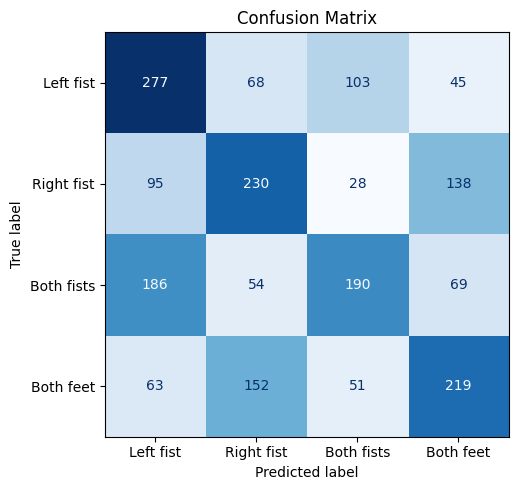

<Figure size 640x480 with 0 Axes>

In [65]:
label_names = ["Left fist", "Right fist", "Both fists", "Both feet"]
evaluate(model, val_loader, device, label_names=label_names)

plot_confusion_matrix(model, val_loader, device, label_names)
plt.savefig('/kaggle/working/confusion_matrix.png')

In [66]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE = get_device()

In [67]:
def model_tuning(model, num_classes: int = 4, device: torch.device = None) -> tuple:
    device = device or DEVICE

    for p in model.parameters():
        p.requires_grad = False

    for p in model.classifier.parameters():
        p.requires_grad = True

    model.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ELU(),
            nn.Linear(256, 128),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Linear(64, num_classes)
    )
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-3,
        weight_decay=1e-4
    )
    for param_group in optimizer.param_groups:
        param_group['lr'] = 3e-3
    scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=20, gamma=0.7  
        )

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  Params: {total:,} total  |  {trainable:,} trainable "
          f"({100 * trainable / total:.1f}%)")

    return model.to(device), optimizer, scheduler

In [87]:
tuned_model = ATCNet_LSTM(n_channels=44, num_classes=4)
tuned_model.load_state_dict(
    torch.load('/kaggle/working/eeg_model_best.pth', weights_only=False),
    strict=False
)

tuned_model, optimizer_ft, scheduler_ft = model_tuning(tuned_model)


  Params: 2,470,484 total  |  172,740 trainable (7.0%)


In [69]:
def augment_eeg(X, noise_std=0.05, shift_max=20):
    X_aug = X.copy()
    N, C, T = X_aug.shape

    X_aug += np.random.randn(*X_aug.shape).astype(np.float32) * noise_std

    shifts = np.random.randint(-shift_max, shift_max, size=N)
    for i, s in enumerate(shifts):
        X_aug[i] = np.roll(X_aug[i], s, axis=-1)

    return X_aug

In [84]:
for f in ["/kaggle/working/cache_train.npy", "/kaggle/working/cache_val.npy"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted old cache: {f}")

builder_tune = EEGDatasetBuilder(DATA_PATH)
X, y_raw, ch_names, subjects = builder_tune.build(tune=1)
 
y, label_encoder = encode_labels(y_raw)
num_classes      = len(label_encoder.classes_)
class_counts = np.bincount(y)
 
# Data augmentation 
X_aug = augment_eeg(X, noise_std=0.03, shift_max=15)
X_all = np.concatenate([X, X_aug], axis=0)
y_all = np.concatenate([y, y], axis=0)
 
print(f"After augmentation: X={X_all.shape}, y={y_all.shape}")
 
train_idx, val_idx = train_test_split(
    np.arange(len(X_all)),
    test_size=0.2,    
    random_state=42,
    stratify=y_all
)
 
X_train_tuning, X_val_tuning = X_all[::], X_all[val_idx]
y_train_tuning, y_val_tuning = y_all[::], y_all[val_idx]
 
train_ds_tuning = EEGTorchDataset(X_train_tuning, y_train_tuning)
val_ds_tuning   = EEGTorchDataset(X_val_tuning,   y_val_tuning) 
 
pin     = torch.cuda.is_available()
sampler = make_weighted_sampler(y_train_tuning)
 
train_loader_tuning = DataLoader(train_ds_tuning, batch_size=32, sampler=sampler,
                                  num_workers=2, pin_memory=pin)
val_loader_tuning   = DataLoader(val_ds_tuning,   batch_size=32, shuffle=False,
                                  num_workers=2, pin_memory=pin)


Total files: 1526  |  After run filter: 654
Total files: 1526  |  After run filter: 654
Skipped: 0 / 12
X shape  : (180, 44, 641)  dtype: float32
y shape  : (180,)  classes: [0 1 2 3]
Per class: [46 44 46 44]
Classes: [0 1 2 3]  →  [0 1 2 3]
After augmentation: X=(360, 44, 641), y=(360,)
Class counts: [92 88 92 88]


In [88]:
train(tuned_model, train_loader_tuning, val_loader_tuning, device, optimizer_ft, scheduler_ft, epochs=200, class_counts=class_counts, patience=50, save_path='/kaggle/working/best_tuned_model.pth')

label_names = ["Left fist", "Right fist", "Both fists", "Both feet"]
evaluate(tuned_model, val_loader_tuning, device, label_names=label_names)

save_model(tuned_model, num_classes, label_encoder, ch_names, matched_ch)

Using weighted loss: [0.24444443 0.25555554 0.24444443 0.25555554]
Epoch 01/200  train_loss=15.92  val_loss=3.68  train_acc=36.7%  val_acc=37.5%  lr=3.00e-03
  val_loss improved → best model saved
Epoch 02/200  train_loss=15.95  val_loss=3.70  train_acc=36.4%  val_acc=41.7%  lr=3.00e-03
  no improvement (1/50)
Epoch 03/200  train_loss=14.39  val_loss=3.70  train_acc=46.4%  val_acc=43.1%  lr=3.00e-03
  no improvement (2/50)
Epoch 04/200  train_loss=15.99  val_loss=3.63  train_acc=37.2%  val_acc=40.3%  lr=3.00e-03
  val_loss improved → best model saved
Epoch 05/200  train_loss=14.87  val_loss=3.54  train_acc=43.6%  val_acc=40.3%  lr=3.00e-03
  val_loss improved → best model saved
Epoch 06/200  train_loss=14.10  val_loss=3.54  train_acc=43.9%  val_acc=43.1%  lr=3.00e-03
  no improvement (1/50)
Epoch 07/200  train_loss=15.04  val_loss=3.53  train_acc=37.5%  val_acc=30.6%  lr=3.00e-03
  val_loss improved → best model saved
Epoch 08/200  train_loss=15.24  val_loss=3.48  train_acc=37.2%  val_

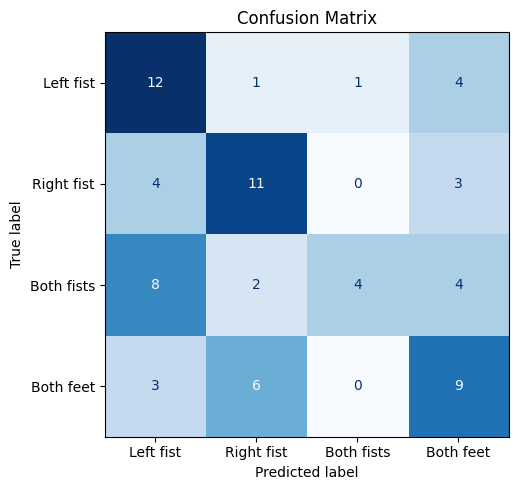

<Figure size 640x480 with 0 Axes>

In [90]:
plot_confusion_matrix(tuned_model, val_loader_tuning, device, label_names)
plt.savefig('/kaggle/working/confusion_matrix_tuned.png')